# Inspect h5 files in /cluster/work/cvg/data/Egoverse/raw_timesynced_h5/

We have two directories in this dataset -- object_in_bowl_processed_50hz and bag_groceries. Let's inspect the h5 files in these directories to understand their structure and contents. I have chosen relatively small files from each directory for this inspection, as the whole dataset is 2-3 TB in size. 

Warning: Arm values are given as position and quaternion of the wrist, not the 7 joint angles. j0-6 label is misleading. 

## object_in_bowl_processed_50hz 

In [2]:
import h5py
import numpy as np
import pandas as pd

h5_path = "20250804_104715.h5"

def is_numeric_dtype(dt):
    return np.issubdtype(dt, np.number) or np.issubdtype(dt, np.bool_)

def summarize_numeric(arr):
    arr = np.asarray(arr)
    if arr.size == 0:
        return {"count": 0}
    flat = arr.ravel()
    if flat.size > 1_000_000:
        # sample for speed on very large datasets
        idx = np.random.default_rng(42).choice(flat.size, 1_000_000, replace=False)
        flat = flat[idx]
    if np.issubdtype(flat.dtype, np.bool_):
        flat = flat.astype(np.int8)
    valid = flat[~np.isnan(flat)] if np.issubdtype(flat.dtype, np.floating) else flat
    if valid.size == 0:
        return {"count": int(flat.size), "valid": 0}
    return {
        "count": int(flat.size),
        "valid": int(valid.size),
        "mean": float(np.mean(valid)),
        "std": float(np.std(valid)),
        "min": float(np.min(valid)),
        "p25": float(np.percentile(valid, 25)),
        "p50": float(np.percentile(valid, 50)),
        "p75": float(np.percentile(valid, 75)),
        "max": float(np.max(valid)),
    }

rows = []

with h5py.File(h5_path, "r") as f:
    def visit(name, obj):
        if isinstance(obj, h5py.Group):
            rows.append({
                "path": name or "/",
                "type": "group",
                "shape": None,
                "dtype": None,
                "attrs": dict(obj.attrs),
                "summary": None
            })
        elif isinstance(obj, h5py.Dataset):
            info = {
                "path": name,
                "type": "dataset",
                "shape": tuple(obj.shape),
                "dtype": str(obj.dtype),
                "attrs": dict(obj.attrs),
                "summary": None
            }
            if is_numeric_dtype(obj.dtype):
                try:
                    data = obj[()]
                    info["summary"] = summarize_numeric(data)
                except Exception as e:
                    info["summary"] = {"error": f"Could not read dataset data: {e}"}
            else:
                info["summary"] = {"note": "non-numeric dataset"}
            rows.append(info)

    f.visititems(visit)

summary_df = pd.DataFrame(rows)

print("=== HDF5 Structure Summary ===")
print(summary_df[["path", "type", "shape", "dtype"]].to_string(index=False))

print("\n=== Numeric Dataset Analytics ===")
numeric_df = summary_df[
    (summary_df["type"] == "dataset")
    & summary_df["summary"].apply(lambda x: isinstance(x, dict) and "mean" in x)
].copy()

if numeric_df.empty:
    print("No numeric datasets found.")
else:
    analytics = pd.json_normalize(numeric_df["summary"])
    out = pd.concat([numeric_df[["path", "shape", "dtype"]].reset_index(drop=True), analytics], axis=1)
    print(out.to_string(index=False))

print("\n=== Attributes (non-empty only) ===")
attrs_df = summary_df[summary_df["attrs"].apply(lambda x: len(x) > 0)][["path", "attrs"]]
if attrs_df.empty:
    print("No attributes found.")
else:
    print(attrs_df.to_string(index=False))

=== HDF5 Structure Summary ===
                                  path    type               shape   dtype
                           actions_arm dataset           (1199, 7) float64
                          actions_hand dataset          (1199, 17) float64
                          observations   group                None     NaN
                   observations/images   group                None     NaN
      observations/images/aria_rgb_cam   group                None     NaN
observations/images/aria_rgb_cam/color dataset (1199, 480, 640, 3)   uint8
                 observations/qpos_arm dataset           (1199, 7) float64
                observations/qpos_hand dataset          (1199, 17) float64

=== Numeric Dataset Analytics ===
                                  path               shape   dtype     count     valid      mean       std       min       p25       p50        p75        max
                           actions_arm           (1199, 7) float64    8393.0    8393.0  0.238015  0.

Using file: 20250804_104715.h5
Selected paths:
  rgb: observations/images/aria_rgb_cam/color
  actions_arm: actions_arm
  actions_hand: actions_hand
  qpos_arm: observations/qpos_arm
  qpos_hand: observations/qpos_hand


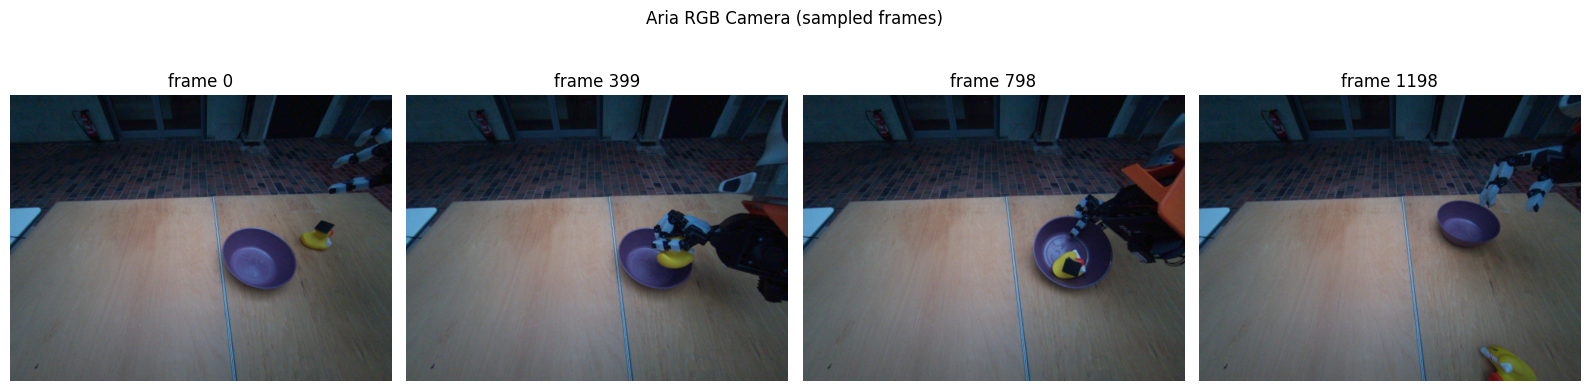

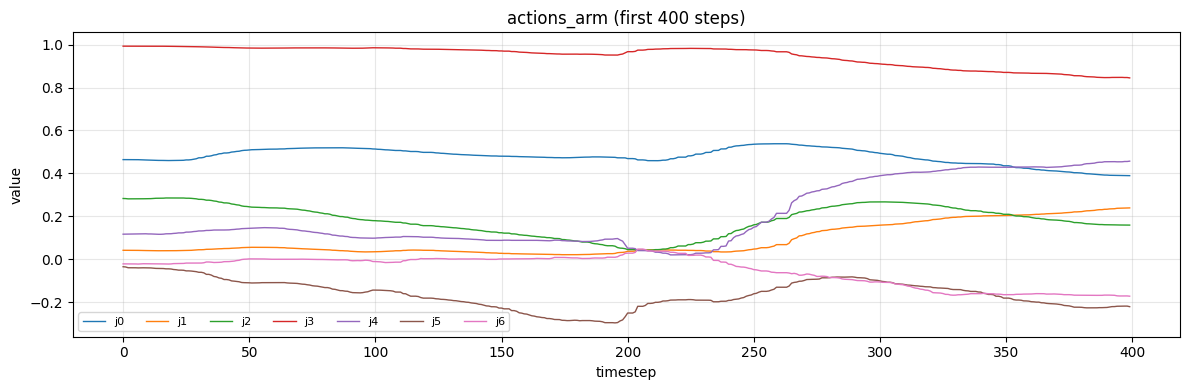

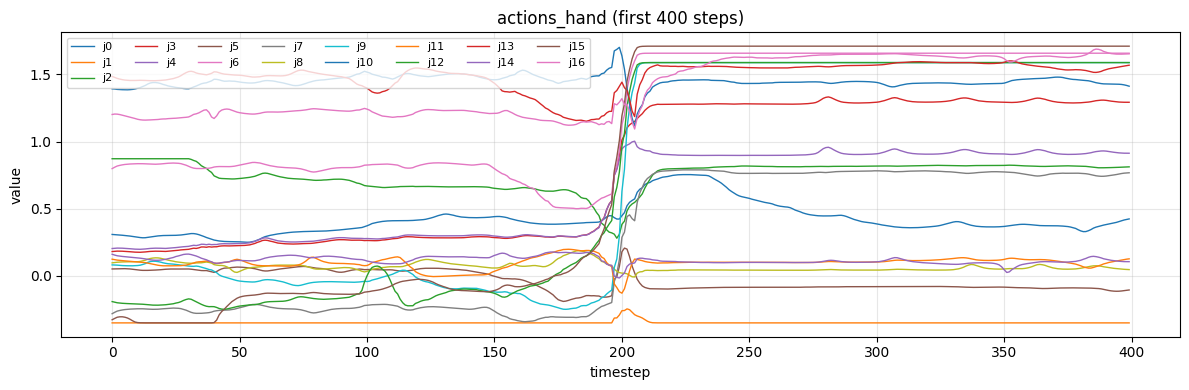

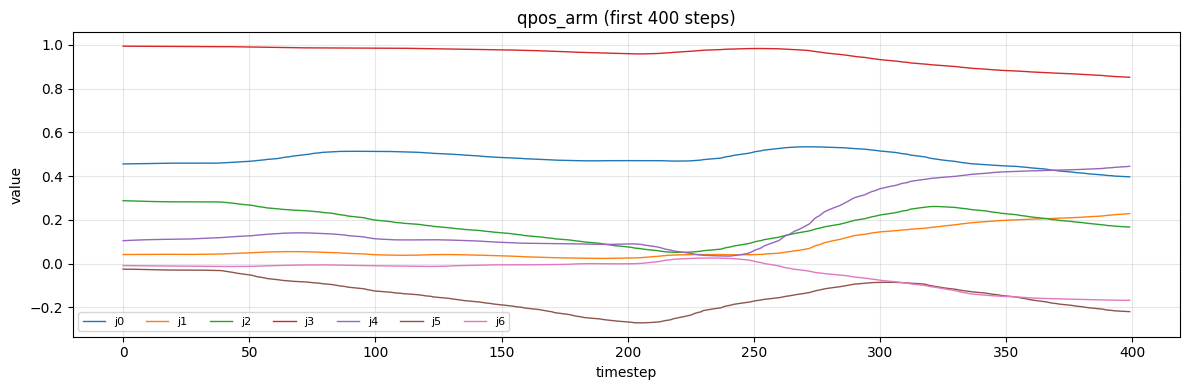

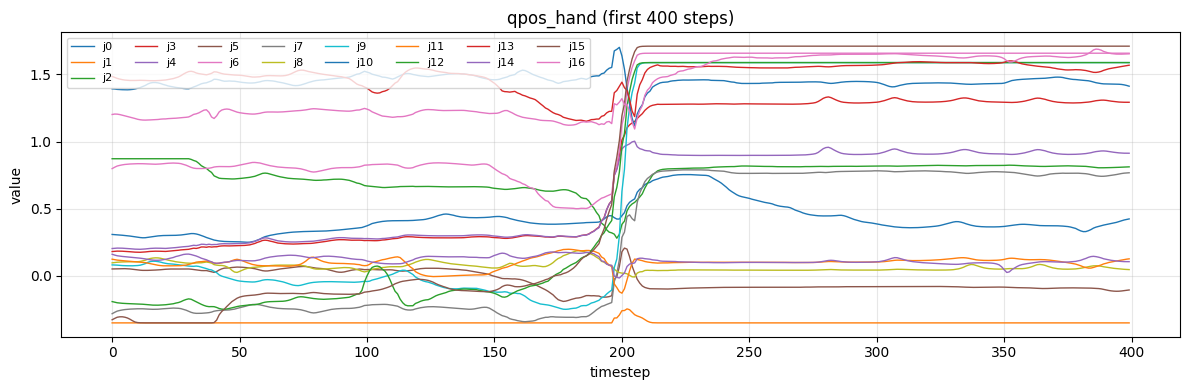

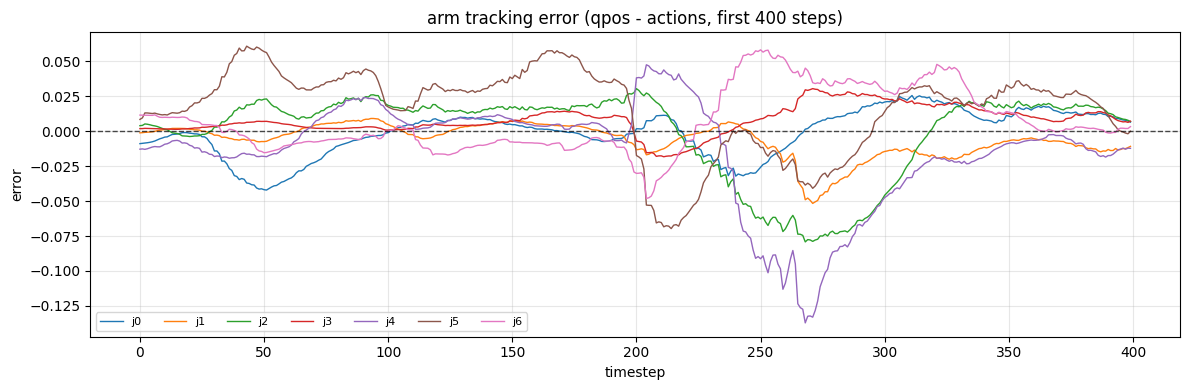

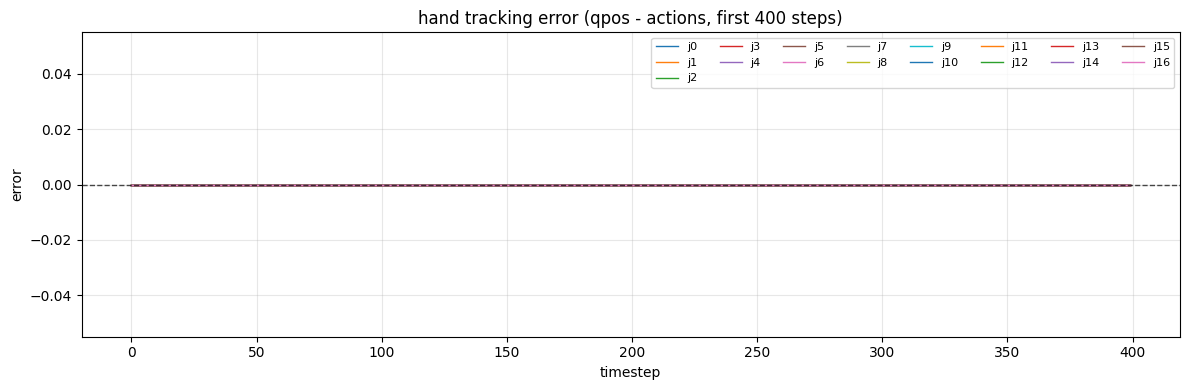

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def resolve_h5_path(preferred_name="20250804_104715.h5", fallback_from_cell1=None):
    candidates = []
    if fallback_from_cell1:
        candidates.append(Path(fallback_from_cell1))
    candidates.append(Path(preferred_name))
    candidates.append(Path.cwd() / preferred_name)

    for candidate in candidates:
        if candidate.is_file():
            return str(candidate)

    for found in Path.cwd().rglob(preferred_name):
        if found.is_file():
            return str(found)

    raise FileNotFoundError(
        f"Could not locate '{preferred_name}' from cwd={Path.cwd()}. "
        "Set h5_path in Cell 1 or move to the workspace root."
    )

def first_existing_path(h5_file, candidates):
    for path in candidates:
        if path in h5_file:
            return path
    return None

def plot_joint_timeseries(data, title, max_dims=None, max_steps=400):
    if data.ndim != 2:
        print(f"{title}: expected 2D array, got shape {data.shape}")
        return

    n_steps = data.shape[0]
    steps = min(n_steps, max_steps)
    dims = data.shape[1] if max_dims is None else min(data.shape[1], max_dims)
    arr = data[:steps, :dims]

    fig, ax = plt.subplots(figsize=(12, 4))
    for joint_idx in range(arr.shape[1]):
        ax.plot(arr[:, joint_idx], label=f"j{joint_idx}", linewidth=1)
    ax.set_title(f"{title} (first {steps} steps)")
    ax.set_xlabel("timestep")
    ax.set_ylabel("value")
    ax.grid(alpha=0.3)
    ax.legend(ncol=min(arr.shape[1], 8), fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_tracking_error(actions, qpos, title, max_dims=None, max_steps=400):
    if actions.ndim != 2 or qpos.ndim != 2:
        print(f"{title}: expected 2D arrays, got actions {actions.shape}, qpos {qpos.shape}")
        return

    steps = min(actions.shape[0], qpos.shape[0], max_steps)
    dims_available = min(actions.shape[1], qpos.shape[1])
    dims = dims_available if max_dims is None else min(dims_available, max_dims)

    if steps == 0 or dims == 0:
        print(f"{title}: no overlapping steps/dimensions to compare")
        return

    err = qpos[:steps, :dims] - actions[:steps, :dims]

    fig, ax = plt.subplots(figsize=(12, 4))
    for joint_idx in range(err.shape[1]):
        ax.plot(err[:, joint_idx], label=f"j{joint_idx}", linewidth=1)
    ax.axhline(0.0, color="black", linewidth=1, linestyle="--", alpha=0.7)
    ax.set_title(f"{title} (qpos - actions, first {steps} steps)")
    ax.set_xlabel("timestep")
    ax.set_ylabel("error")
    ax.grid(alpha=0.3)
    ax.legend(ncol=min(err.shape[1], 8), fontsize=8)
    plt.tight_layout()
    plt.show()

h5_path_local = resolve_h5_path(
    preferred_name="20250804_104715.h5",
    fallback_from_cell1=globals().get("h5_path", None),
)

with h5py.File(h5_path_local, "r") as f:
    rgb_path = first_existing_path(
        f,
        [
            "observations/images/aria_rgb_cam/color",
            "observations/images/aria_rgb_cam",
            "aria_rgb_cam/color",
            "aria_rgb_cam",
        ],
    )
    actions_arm_path = first_existing_path(f, ["actions_arm", "actions/arm"])
    actions_hand_path = first_existing_path(f, ["actions_hand", "actions/hand"])
    qpos_arm_path = first_existing_path(f, ["observations/qpos_arm", "qpos_arm", "observations/qpos/arm"])
    qpos_hand_path = first_existing_path(f, ["observations/qpos_hand", "qpos_hand", "observations/qpos/hand"])

    print("Using file:", h5_path_local)
    print("Selected paths:")
    print("  rgb:", rgb_path)
    print("  actions_arm:", actions_arm_path)
    print("  actions_hand:", actions_hand_path)
    print("  qpos_arm:", qpos_arm_path)
    print("  qpos_hand:", qpos_hand_path)

    actions_arm = f[actions_arm_path][()] if actions_arm_path is not None else None
    actions_hand = f[actions_hand_path][()] if actions_hand_path is not None else None
    qpos_arm = f[qpos_arm_path][()] if qpos_arm_path is not None else None
    qpos_hand = f[qpos_hand_path][()] if qpos_hand_path is not None else None

    if rgb_path is not None:
        rgb_ds = f[rgb_path]
        n_frames = rgb_ds.shape[0]
        sample_idx = np.linspace(0, n_frames - 1, 4, dtype=int)

        fig, axes = plt.subplots(1, len(sample_idx), figsize=(16, 4))
        if len(sample_idx) == 1:
            axes = [axes]
        for ax, idx in zip(axes, sample_idx):
            ax.imshow(rgb_ds[idx])
            ax.set_title(f"frame {idx}")
            ax.axis("off")
        plt.suptitle("Aria RGB Camera (sampled frames)", y=1.03)
        plt.tight_layout()
        plt.show()
    else:
        print("RGB camera dataset not found.")

    if actions_arm is not None:
        plot_joint_timeseries(actions_arm, "actions_arm")
    if actions_hand is not None:
        plot_joint_timeseries(actions_hand, "actions_hand")
    if qpos_arm is not None:
        plot_joint_timeseries(qpos_arm, "qpos_arm")
    if qpos_hand is not None:
        plot_joint_timeseries(qpos_hand, "qpos_hand")

    if actions_arm is not None and qpos_arm is not None:
        plot_tracking_error(actions_arm, qpos_arm, "arm tracking error")
    else:
        print("Skipping arm tracking error (missing actions_arm or qpos_arm).")

    if actions_hand is not None and qpos_hand is not None:
        plot_tracking_error(actions_hand, qpos_hand, "hand tracking error")
    else:
        print("Skipping hand tracking error (missing actions_hand or qpos_hand).")

## bag_groceries 

In [4]:
import h5py
import numpy as np
import pandas as pd

h5_path = "20250829_180500.h5"

def is_numeric_dtype(dt):
    return np.issubdtype(dt, np.number) or np.issubdtype(dt, np.bool_)

def summarize_numeric(arr):
    arr = np.asarray(arr)
    if arr.size == 0:
        return {"count": 0}
    flat = arr.ravel()
    if flat.size > 1_000_000:
        # sample for speed on very large datasets
        idx = np.random.default_rng(42).choice(flat.size, 1_000_000, replace=False)
        flat = flat[idx]
    if np.issubdtype(flat.dtype, np.bool_):
        flat = flat.astype(np.int8)
    valid = flat[~np.isnan(flat)] if np.issubdtype(flat.dtype, np.floating) else flat
    if valid.size == 0:
        return {"count": int(flat.size), "valid": 0}
    return {
        "count": int(flat.size),
        "valid": int(valid.size),
        "mean": float(np.mean(valid)),
        "std": float(np.std(valid)),
        "min": float(np.min(valid)),
        "p25": float(np.percentile(valid, 25)),
        "p50": float(np.percentile(valid, 50)),
        "p75": float(np.percentile(valid, 75)),
        "max": float(np.max(valid)),
    }

rows = []

with h5py.File(h5_path, "r") as f:
    def visit(name, obj):
        if isinstance(obj, h5py.Group):
            rows.append({
                "path": name or "/",
                "type": "group",
                "shape": None,
                "dtype": None,
                "attrs": dict(obj.attrs),
                "summary": None
            })
        elif isinstance(obj, h5py.Dataset):
            info = {
                "path": name,
                "type": "dataset",
                "shape": tuple(obj.shape),
                "dtype": str(obj.dtype),
                "attrs": dict(obj.attrs),
                "summary": None
            }
            if is_numeric_dtype(obj.dtype):
                try:
                    data = obj[()]
                    info["summary"] = summarize_numeric(data)
                except Exception as e:
                    info["summary"] = {"error": f"Could not read dataset data: {e}"}
            else:
                info["summary"] = {"note": "non-numeric dataset"}
            rows.append(info)

    f.visititems(visit)

summary_df = pd.DataFrame(rows)

print("=== HDF5 Structure Summary ===")
print(summary_df[["path", "type", "shape", "dtype"]].to_string(index=False))

print("\n=== Numeric Dataset Analytics ===")
numeric_df = summary_df[
    (summary_df["type"] == "dataset")
    & summary_df["summary"].apply(lambda x: isinstance(x, dict) and "mean" in x)
].copy()

if numeric_df.empty:
    print("No numeric datasets found.")
else:
    analytics = pd.json_normalize(numeric_df["summary"])
    out = pd.concat([numeric_df[["path", "shape", "dtype"]].reset_index(drop=True), analytics], axis=1)
    print(out.to_string(index=False))

print("\n=== Attributes (non-empty only) ===")
attrs_df = summary_df[summary_df["attrs"].apply(lambda x: len(x) > 0)][["path", "attrs"]]
if attrs_df.empty:
    print("No attributes found.")
else:
    print(attrs_df.to_string(index=False))

=== HDF5 Structure Summary ===
                                     path    type               shape   dtype
                         actions_arm_left dataset           (1928, 7) float64
                        actions_arm_right dataset           (1928, 7) float64
                        actions_hand_left dataset          (1928, 17) float64
                       actions_hand_right dataset          (1928, 17) float64
                             observations   group                None     NaN
                      observations/images   group                None     NaN
         observations/images/aria_rgb_cam   group                None     NaN
   observations/images/aria_rgb_cam/color dataset (1928, 480, 640, 3)   uint8
      observations/images/oakd_front_view   group                None     NaN
observations/images/oakd_front_view/color dataset (1928, 540, 960, 3)   uint8
               observations/qpos_arm_left dataset           (1928, 7) float64
              observations/qpos_a

Using file: 20250829_180500.h5
Detected camera datasets:
  observations/images/aria_rgb_cam/color
  observations/images/oakd_front_view/color
Detected action datasets:
  actions_arm_left
  actions_arm_right
  actions_hand_left
  actions_hand_right
Detected qpos datasets:
  observations/qpos_arm_left
  observations/qpos_arm_right
  observations/qpos_hand_left
  observations/qpos_hand_right
Detected action↔qpos pairs:
  actions_arm_left  <->  observations/qpos_arm_left
  actions_arm_right  <->  observations/qpos_arm_right
  actions_hand_left  <->  observations/qpos_hand_left
  actions_hand_right  <->  observations/qpos_hand_right


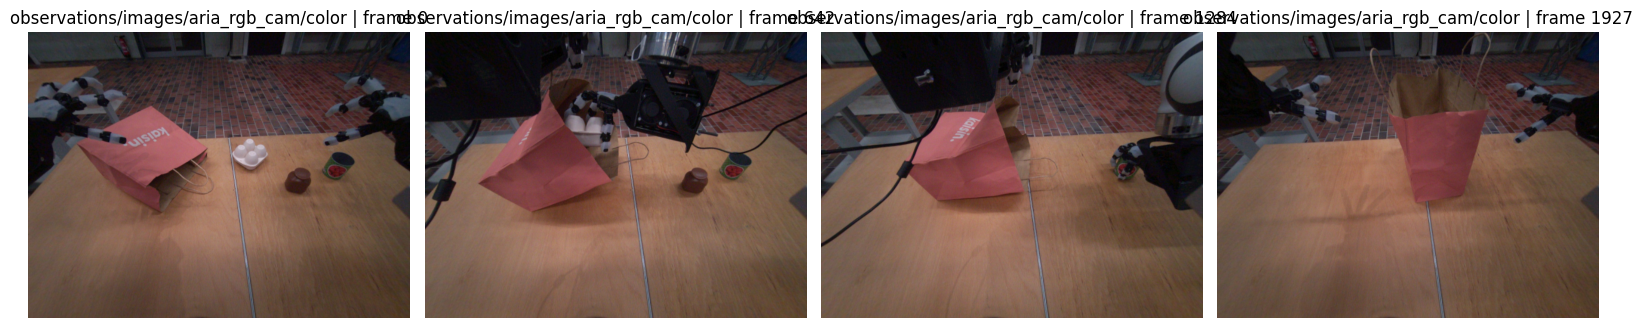

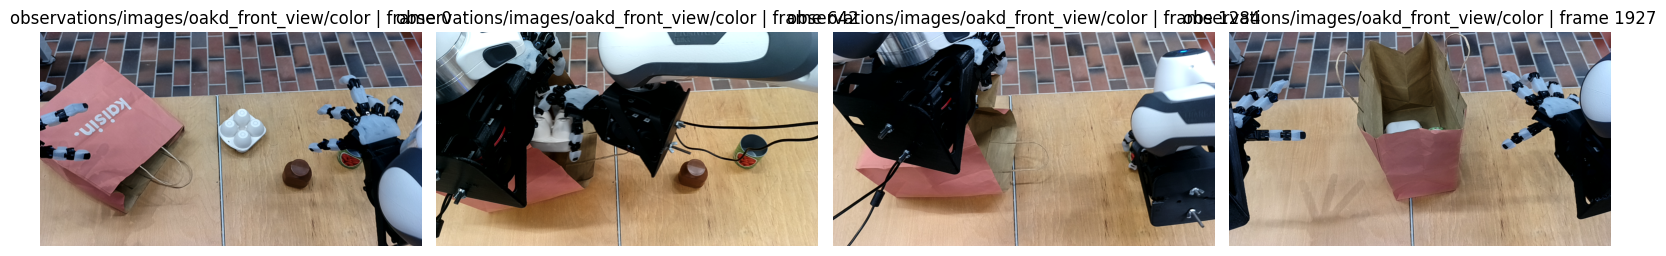

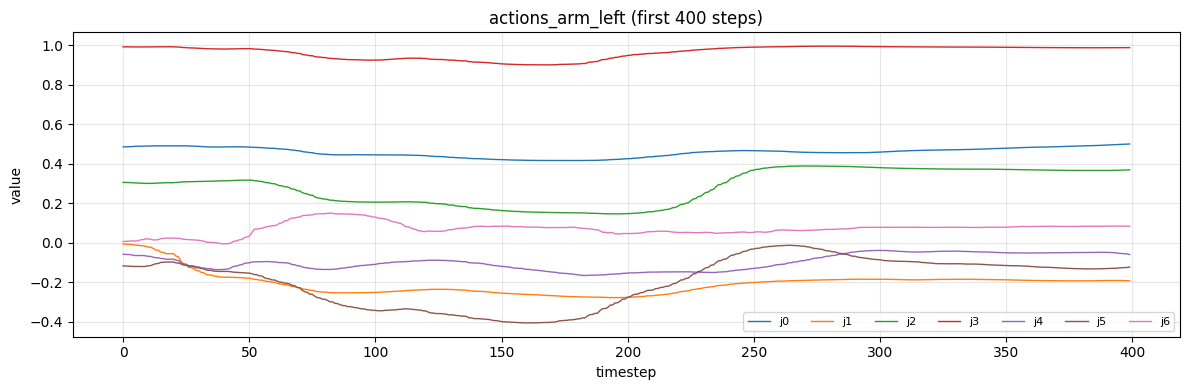

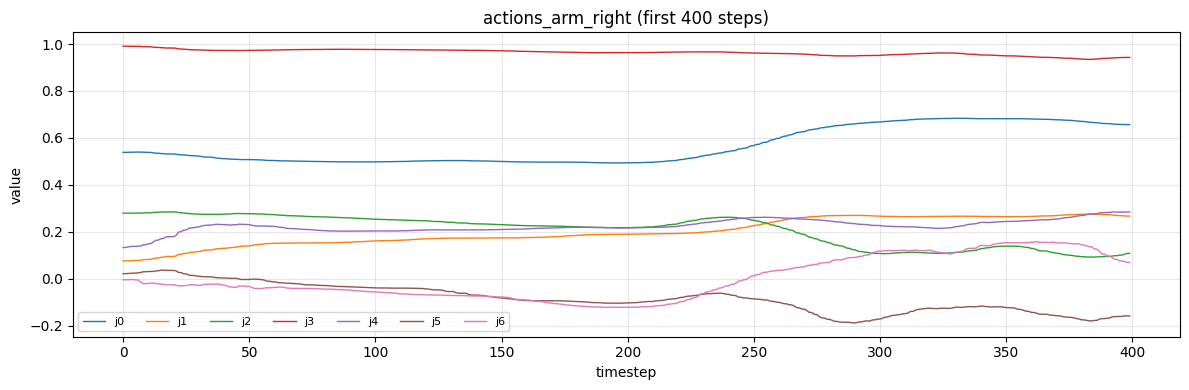

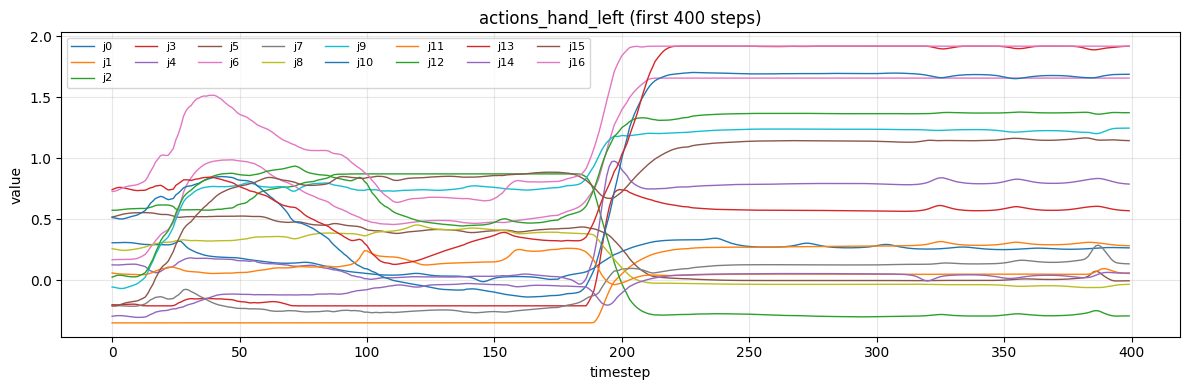

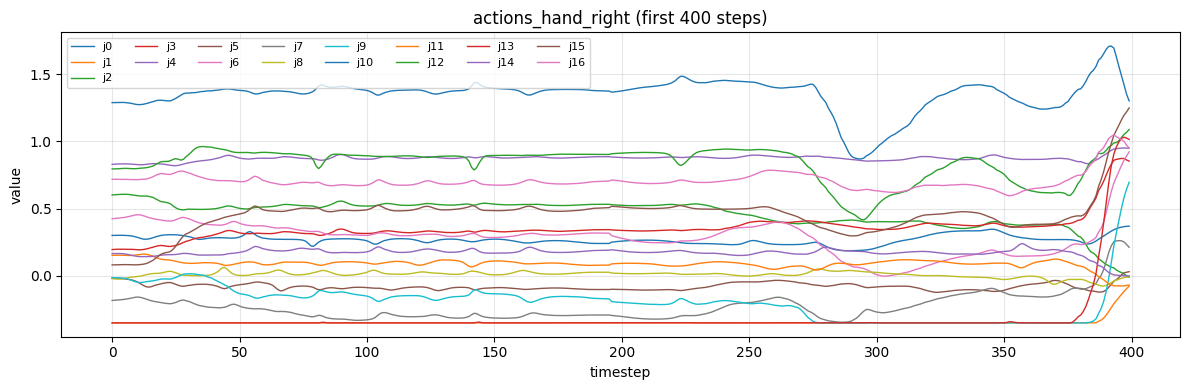

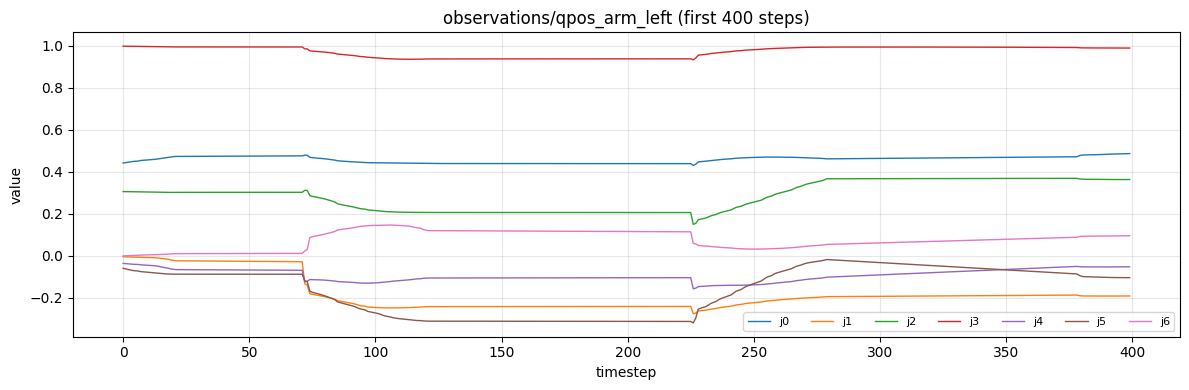

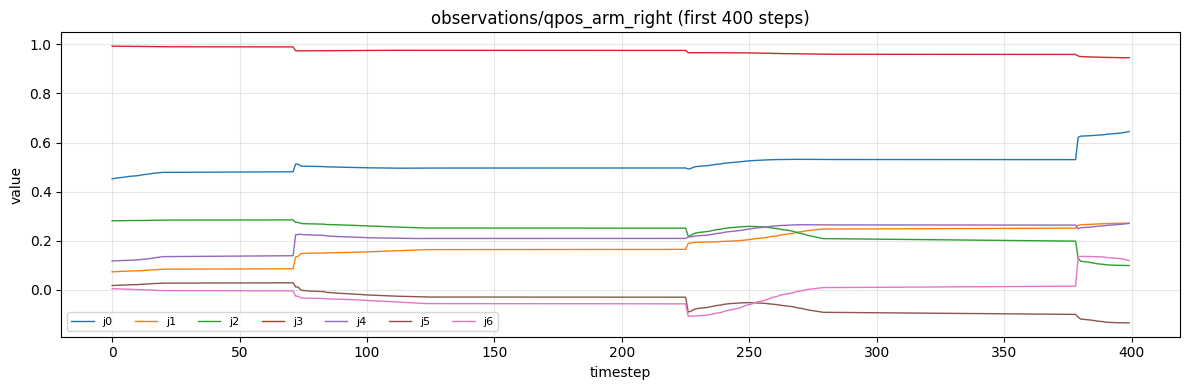

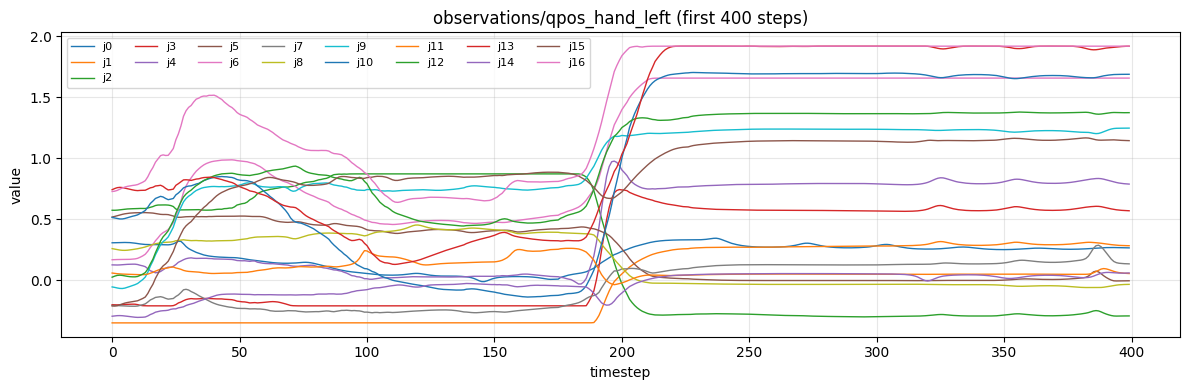

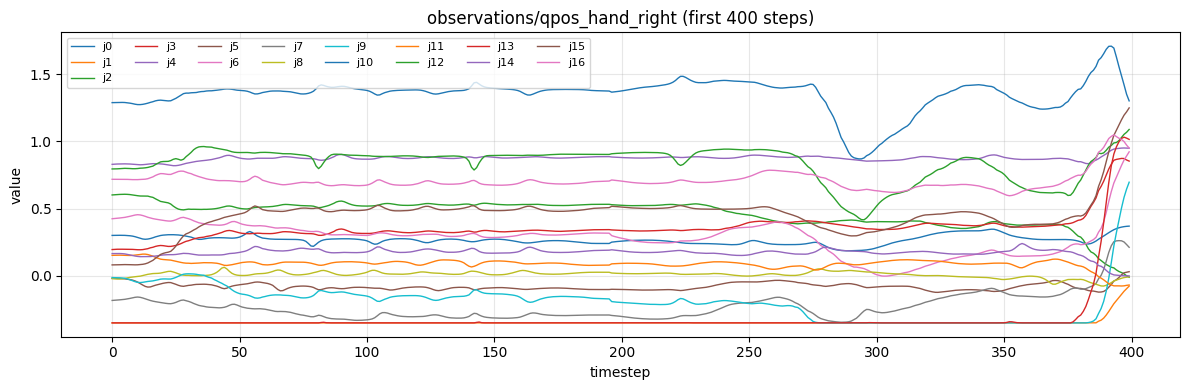

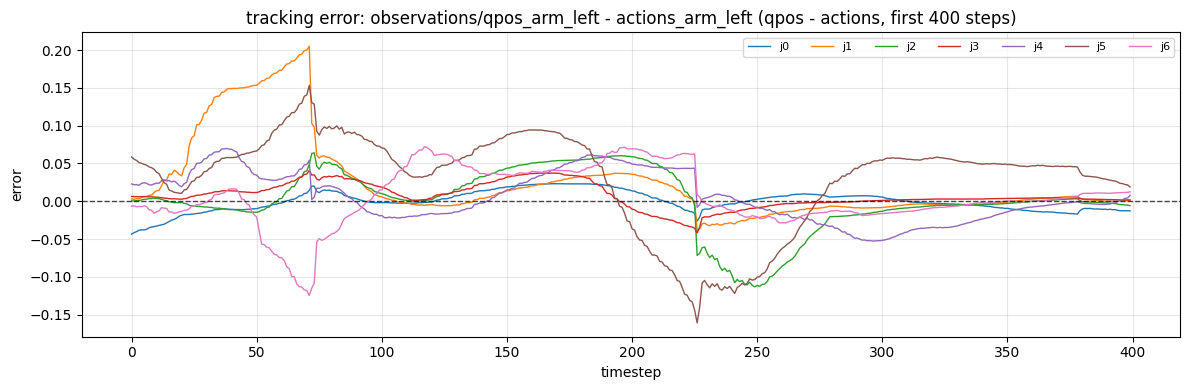

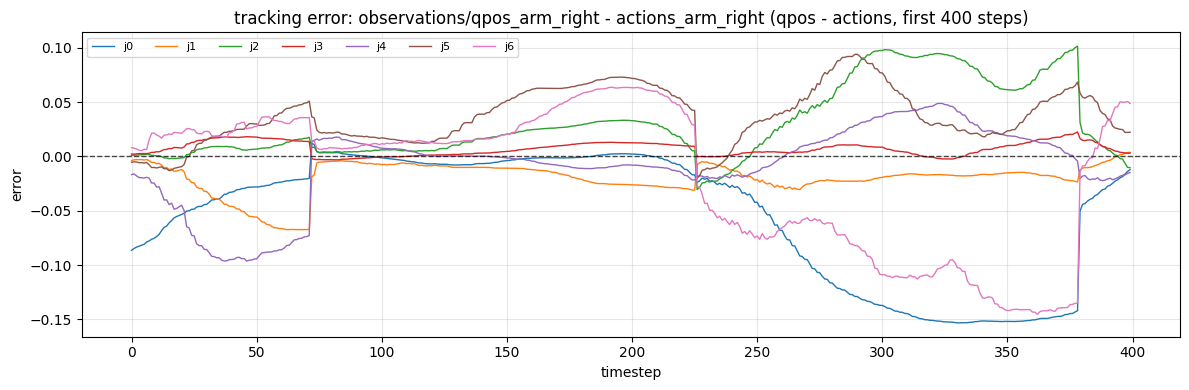

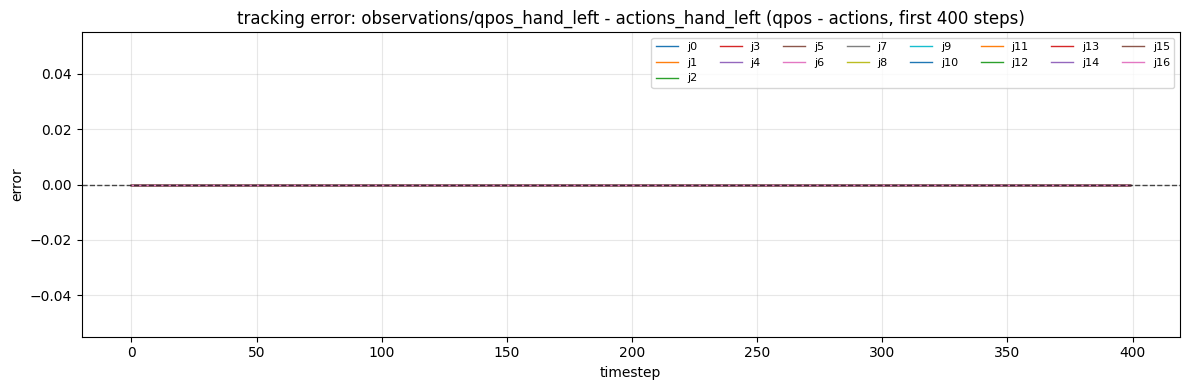

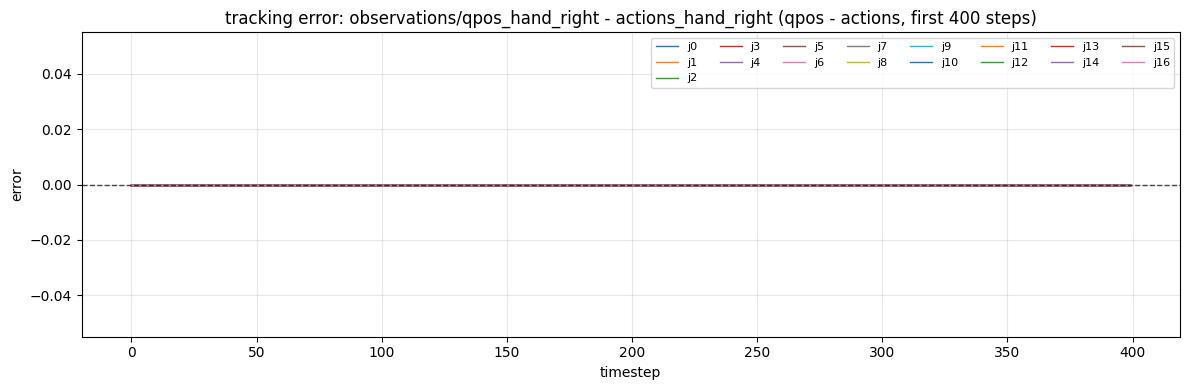

In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def resolve_h5_path(preferred_name="20250829_180500.h5", fallback_from_cell1=None):
    candidates = []
    if fallback_from_cell1:
        candidates.append(Path(fallback_from_cell1))
    candidates.append(Path(preferred_name))
    candidates.append(Path.cwd() / preferred_name)

    for candidate in candidates:
        if candidate.is_file():
            return str(candidate)

    for found in Path.cwd().rglob(preferred_name):
        if found.is_file():
            return str(found)

    raise FileNotFoundError(
        f"Could not locate '{preferred_name}' from cwd={Path.cwd()}. "
        "Set h5_path in the section's summary cell or move to the workspace root."
    )

def collect_dataset_shapes(h5_file):
    dataset_shapes = {}

    def visit(name, obj):
        if isinstance(obj, h5py.Dataset):
            dataset_shapes[name] = tuple(obj.shape)

    h5_file.visititems(visit)
    return dataset_shapes

def plot_joint_timeseries(data, title, max_dims=None, max_steps=400):
    if data.ndim != 2:
        print(f"{title}: expected 2D array, got shape {data.shape}")
        return

    steps = min(data.shape[0], max_steps)
    dims = data.shape[1] if max_dims is None else min(data.shape[1], max_dims)
    arr = data[:steps, :dims]

    fig, ax = plt.subplots(figsize=(12, 4))
    for joint_idx in range(arr.shape[1]):
        ax.plot(arr[:, joint_idx], label=f"j{joint_idx}", linewidth=1)
    ax.set_title(f"{title} (first {steps} steps)")
    ax.set_xlabel("timestep")
    ax.set_ylabel("value")
    ax.grid(alpha=0.3)
    ax.legend(ncol=min(arr.shape[1], 8), fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_tracking_error(actions, qpos, title, max_dims=None, max_steps=400):
    if actions.ndim != 2 or qpos.ndim != 2:
        print(f"{title}: expected 2D arrays, got actions {actions.shape}, qpos {qpos.shape}")
        return

    steps = min(actions.shape[0], qpos.shape[0], max_steps)
    dims_available = min(actions.shape[1], qpos.shape[1])
    dims = dims_available if max_dims is None else min(dims_available, max_dims)

    if steps == 0 or dims == 0:
        print(f"{title}: no overlapping steps/dimensions to compare")
        return

    err = qpos[:steps, :dims] - actions[:steps, :dims]

    fig, ax = plt.subplots(figsize=(12, 4))
    for joint_idx in range(err.shape[1]):
        ax.plot(err[:, joint_idx], label=f"j{joint_idx}", linewidth=1)
    ax.axhline(0.0, color="black", linewidth=1, linestyle="--", alpha=0.7)
    ax.set_title(f"{title} (qpos - actions, first {steps} steps)")
    ax.set_xlabel("timestep")
    ax.set_ylabel("error")
    ax.grid(alpha=0.3)
    ax.legend(ncol=min(err.shape[1], 8), fontsize=8)
    plt.tight_layout()
    plt.show()

h5_path_local = resolve_h5_path(
    preferred_name="20250829_180500.h5",
    fallback_from_cell1=globals().get("h5_path", None),
)

with h5py.File(h5_path_local, "r") as f:
    dataset_shapes = collect_dataset_shapes(f)
    dataset_paths = sorted(dataset_shapes.keys())

    camera_paths = [
        path
        for path in dataset_paths
        if path.endswith("/color")
        and len(dataset_shapes[path]) == 4
        and dataset_shapes[path][-1] in (1, 3, 4)
    ]

    action_paths = sorted([path for path in dataset_paths if path.startswith("actions_")])
    qpos_paths = sorted([path for path in dataset_paths if path.startswith("observations/qpos_")])

    action_qpos_pairs = []
    for action_path in action_paths:
        suffix = action_path[len("actions_"):]
        qpos_path = f"observations/qpos_{suffix}"
        if qpos_path in dataset_shapes:
            action_qpos_pairs.append((action_path, qpos_path))

    print("Using file:", h5_path_local)
    print("Detected camera datasets:")
    print("  " + "\n  ".join(camera_paths) if camera_paths else "  None")
    print("Detected action datasets:")
    print("  " + "\n  ".join(action_paths) if action_paths else "  None")
    print("Detected qpos datasets:")
    print("  " + "\n  ".join(qpos_paths) if qpos_paths else "  None")
    print("Detected action↔qpos pairs:")
    if action_qpos_pairs:
        for a_path, q_path in action_qpos_pairs:
            print(f"  {a_path}  <->  {q_path}")
    else:
        print("  None")

    for cam_path in camera_paths:
        rgb_ds = f[cam_path]
        n_frames = rgb_ds.shape[0]
        sample_idx = np.linspace(0, n_frames - 1, 4, dtype=int)

        fig, axes = plt.subplots(1, len(sample_idx), figsize=(16, 4))
        if len(sample_idx) == 1:
            axes = [axes]
        for ax, idx in zip(axes, sample_idx):
            ax.imshow(rgb_ds[idx])
            ax.set_title(f"{cam_path} | frame {idx}")
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    for action_path in action_paths:
        plot_joint_timeseries(f[action_path][()], action_path)

    for qpos_path in qpos_paths:
        plot_joint_timeseries(f[qpos_path][()], qpos_path)

    for action_path, qpos_path in action_qpos_pairs:
        title = f"tracking error: {qpos_path} - {action_path}"
        plot_tracking_error(f[action_path][()], f[qpos_path][()], title)

In [ ]:
import h5py
import imageio
from pathlib import Path

# ── Configuration ──────────────────────────────────────────────────────────────
# FPS confirmed by dataset directory name: object_in_bowl_processed_50hz
FPS = 50

FILES = {
    "20250804_104715.h5": [
        "observations/images/aria_rgb_cam/color",
    ],
    "20250829_180500.h5": [
        "observations/images/aria_rgb_cam/color",
        "observations/images/oakd_front_view/color",
    ],
}

# ── Export ─────────────────────────────────────────────────────────────────────
for h5_name, cam_paths in FILES.items():
    stem = Path(h5_name).stem
    with h5py.File(h5_name, "r") as f:
        for cam_path in cam_paths:
            if cam_path not in f:
                print(f"[SKIP] {cam_path} not found in {h5_name}")
                continue

            cam_tag = cam_path.split("/")[-2]  # e.g. aria_rgb_cam, oakd_front_view
            out_path = f"../outputs/{stem}_{cam_tag}.mp4"

            ds = f[cam_path]
            n_frames = ds.shape[0]
            print(f"Writing {out_path}  ({n_frames} frames @ {FPS} fps) ...", flush=True)

            with imageio.get_writer(out_path, fps=FPS, macro_block_size=None) as writer:
                for i in range(n_frames):
                    writer.append_data(ds[i])
                    if (i + 1) % 200 == 0:
                        print(f"  {i + 1}/{n_frames}", end="\r", flush=True)

            print(f"  Saved -> {out_path}")


Writing 20250804_104715_aria_rgb_cam.mp4  (1199 frames @ 50 fps) ...
  Saved -> 20250804_104715_aria_rgb_cam.mp4
Writing 20250829_180500_aria_rgb_cam.mp4  (1928 frames @ 50 fps) ...
  Saved -> 20250829_180500_aria_rgb_cam.mp4
Writing 20250829_180500_oakd_front_view.mp4  (1928 frames @ 50 fps) ...
  Saved -> 20250829_180500_oakd_front_view.mp4
